In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Sadece 200k satır oku 
df = pd.read_csv('../data/musteri_tweetleri.csv', nrows=200000)

print(f"Veri yüklendi: {df.shape}")
df.head()

Veri yüklendi: (200000, 9)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,clean_text,kategori
0,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,propose,General
1,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0,sent several private messages one responding u...,General
2,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0,did.,General
3,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN,worst customer service,General
4,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15.0,gonna magically change connectivity whole family,General


In [3]:
# Sentiment etiketi oluştur — kural bazlı
pozitif_kelimeler = ['thank', 'thanks', 'great', 'awesome', 'love', 
                      'perfect', 'excellent', 'amazing', 'good', 'happy',
                      'resolved', 'fixed', 'helped', 'wonderful', 'best',
                      'appreciate', 'pleased', 'satisfied', 'quick', 'fast',
                      'easy', 'brilliant', 'superb', 'fantastic', 'glad',
                      'relief', 'sorted', 'working', 'solved', 'nice']

negatif_kelimeler = ['problem', 'issue', 'broken', 'terrible', 'awful',
                      'worst', 'angry', 'frustrated', 'disappointed', 'bad',
                      'horrible', 'useless', 'never', 'ridiculous', 'unacceptable',
                      'waiting', 'delayed', 'cancelled', 'charged', 'wrong',
                      'error', 'failed', 'unable', 'cant', 'still', 'hours',
                      'days', 'weeks', 'complaint', 'refund', 'stuck', 'lost']

def sentiment_belirle(text):
    text = str(text).lower()
    poz = sum(1 for k in pozitif_kelimeler if k in text)
    neg = sum(1 for k in negatif_kelimeler if k in text)
    if poz > neg:
        return 'Pozitif'
    elif neg > poz:
        return 'Negatif'
    else:
        return 'Nötr'

df['sentiment'] = df['clean_text'].apply(sentiment_belirle)

print(f"Sentiment dağılımı:\n{df['sentiment'].value_counts()}")

Sentiment dağılımı:
sentiment
Nötr       124389
Negatif     45183
Pozitif     30428
Name: count, dtype: int64


Veri boyutu: (75611, 10)

Sentiment dağılımı:
sentiment
Negatif    45183
Pozitif    30428
Name: count, dtype: int64


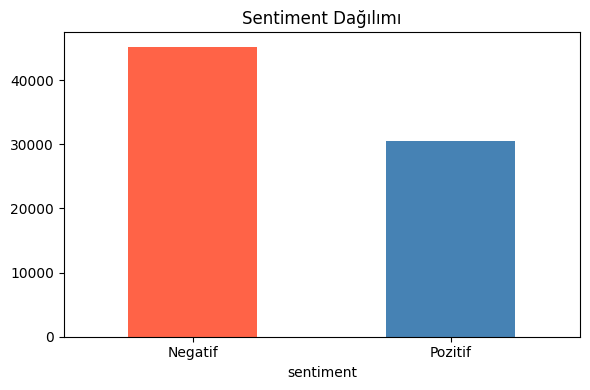

In [4]:
# Nötr'ü çıkar
df_sentiment = df[df['sentiment'] != 'Nötr'].copy()

print(f"Veri boyutu: {df_sentiment.shape}")
print(f"\nSentiment dağılımı:\n{df_sentiment['sentiment'].value_counts()}")

# Görselleştir
df_sentiment['sentiment'].value_counts().plot(
    kind='bar', color=['tomato', 'steelblue'], figsize=(6,4)
)
plt.title('Sentiment Dağılımı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Özellikler ve hedef
X = df_sentiment['clean_text'].fillna('')
y = df_sentiment['sentiment']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
tfidf_sentiment = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf_sentiment.fit_transform(X_train)
X_test_tfidf = tfidf_sentiment.transform(X_test)

# Model
sentiment_model = LogisticRegression(max_iter=1000, random_state=42)
sentiment_model.fit(X_train_tfidf, y_train)

# Tahmin
y_pred = sentiment_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Negatif       0.98      1.00      0.99      9037
     Pozitif       1.00      0.97      0.99      6086

    accuracy                           0.99     15123
   macro avg       0.99      0.99      0.99     15123
weighted avg       0.99      0.99      0.99     15123



In [ ]:
import pickle

with open('../data/sentiment_model.pkl', 'wb') as f:
    pickle.dump(sentiment_model, f)

with open('../data/tfidf_sentiment.pkl', 'wb') as f:
    pickle.dump(tfidf_sentiment, f)

print("Sentiment modeli kaydedildi!")